## Short 
Diego Dueñas Martín  
751426  
09/02/2026

## Ejercicio de long y short

## Contexto del ejercicio

Este notebook compara dos formas de pensar el pago (payoff) de opciones financieras tipo call y put:

- Un primer acercamiento ingenuo, donde el precio del subyacente al vencimiento se genera con una distribución uniforme, solo para visualizar la forma de las funciones de pago.
- Un segundo acercamiento, ya en la sección de trabajo en equipo, donde el precio se simula con Movimiento Browniano Geométrico (GBM) bajo la medida neutral al riesgo —el modelo detrás de Black-Scholes— y se usa para estimar la ganancia esperada de call y put bajo distintos escenarios de volatilidad, tasa y plazo.

### Diccionario rápido

| Término | Significado |
|---|---|
| $S$ | Precio spot (actual) del subyacente |
| $S_T$ | Precio del subyacente al vencimiento (variable aleatoria) |
| $K$ | Precio strike (precio de ejercicio) |
| $r$ | Tasa libre de riesgo |
| $\sigma$ | Volatilidad anualizada del subyacente |
| $T$ | Tiempo a vencimiento, en años |
| $M$ | Número de simulaciones Monte Carlo |
| Call | Opción que paga $\max(S_T - K, 0)$ |
| Put | Opción que paga $\max(K - S_T, 0)$ |
| GBM | Movimiento Browniano Geométrico, el modelo estándar para simular trayectorias de precios |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Primer acercamiento: payoff en función de un rango de precios

Antes de simular trayectorias reales, conviene ver la forma de las funciones de pago. Aquí se generan 10,000 valores de $S_T$ distribuidos uniformemente entre 50 y 200 —no representan un modelo de precios real, solo barren el rango de posibles valores del subyacente para ver cómo se comporta el payoff en cada extremo.

Con un strike $K = 100$:

$$\text{Payoff Call} = \max(S_T - K,\ 0)$$
$$\text{Payoff Put} = \max(K - S_T,\ 0)$$

El call gana cuando el precio termina por encima del strike; el put gana cuando termina por debajo.

In [2]:
# Call 
k = 100
st = np.random.uniform(50, 200, 10000)

ganancia_call = np.maximum(st - k, 0)
ganancia_put = np.maximum(k - st, 0)



## Visualización: distribución de los pagos

El histograma muestra qué tan seguido cae cada payoff en cierto rango de ganancia. Como $S_T$ se generó uniforme, la forma que se ve es prácticamente la forma cruda de la función $\max(\cdot,\ 0)$: una masa grande en cero, cuando la opción no se ejerce, y una cola que crece conforme el precio se aleja del strike.

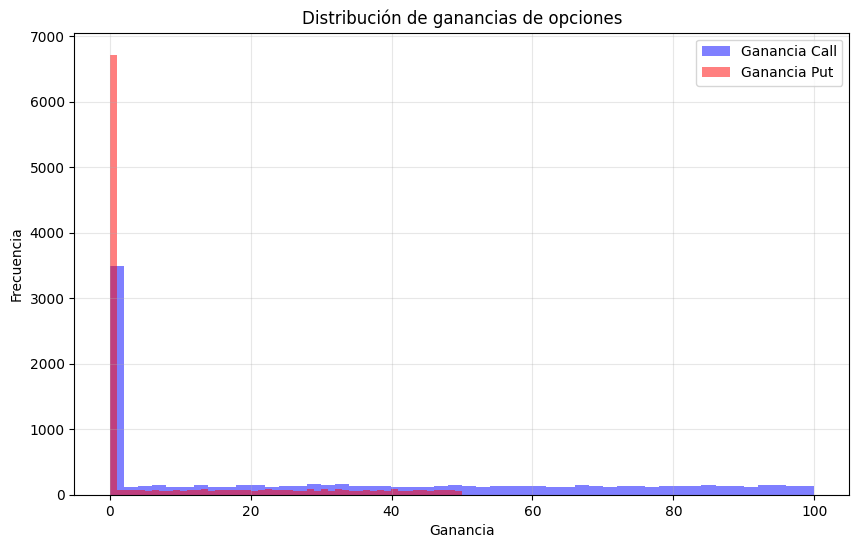

In [3]:
# Graficar la ganancia de las opciones call y put

plt.figure(figsize=(10, 6))

plt.hist(
    ganancia_call,
    bins=50,
    alpha=0.5,
    label="Ganancia Call",
    color="blue"
)

plt.hist(
    ganancia_put,
    bins=50,
    alpha=0.5,
    label="Ganancia Put",
    color="red"
)

plt.xlabel("Ganancia")
plt.ylabel("Frecuencia")
plt.title("Distribución de ganancias de opciones")
plt.legend()
plt.grid(alpha=0.3)
plt.show()   

## Trabajo en equipo 

## De un rango arbitrario a un modelo de precios

En esta sección el precio ya no se sortea uniforme: se simula con Movimiento Browniano Geométrico (GBM) bajo la medida neutral al riesgo, el modelo que sostiene a Black-Scholes-Merton. La idea nació en los años setenta con Black, Scholes y Merton, y hoy sigue siendo el punto de partida estándar para simular cómo se mueve el precio de un activo hacia el futuro.

La lógica, paso a paso:

1. Se parte del precio spot $S$.
2. Se le aplica una deriva ajustada por riesgo: $\left(r - \tfrac{1}{2}\sigma^2\right)$, multiplicada por el tiempo $T$.
3. Se le suma un componente aleatorio: $\sigma\sqrt{T}\,Z$, con $Z \sim N(0,1)$ representando el choque aleatorio de cada simulación.
4. Todo el exponente se aplica sobre $S$ para garantizar que el precio nunca sea negativo.

$$S_T = S \cdot \exp\left[\left(r - \frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right]$$

Se generan $M = 10{,}000$ trayectorias (una por cada valor de $Z$), y `ST` termina siendo un arreglo con los 10,000 precios posibles al vencimiento.

In [4]:
np.random.seed(42)
S = 100
k = 100
r = 0.05
sigma = 0.2
T = 1 
M = 10000

Z = np.random.normal(0, 1, M)

ST = S*np.exp((r - (0.5 * sigma ** 2)) * T + sigma * np.sqrt(T) * Z)
ST

array([113.8080226 , 100.23498965, 117.29684912, ...,  89.4882061 ,
       113.78643345, 117.21945676], shape=(10000,))

## Payoff sobre las trayectorias simuladas

Con `ST` ya generado bajo GBM, se calculan los payoffs igual que antes: $\max(S_T - K, 0)$ para el call y $\max(K - S_T, 0)$ para el put.

> Nota: en esta celda `simul_put` se calcula con `st` —la variable uniforme de la primera sección— y no con `ST`, la simulación GBM recién generada. Si la intención era comparar call y put sobre la misma trayectoria de precios, vale la pena revisar si fue un descuido al copiar el código de la sección anterior.

In [5]:
simul_call = np.maximum(ST - k,0)
simul_put = np.maximum(k - st, 0)

## Comparando las distribuciones simuladas

Este histograma compara la distribución de pagos del call y del put ya bajo el modelo GBM. A diferencia del primer histograma, aquí la forma sí refleja cómo se comporta realmente el precio de un activo bajo movimiento browniano geométrico: asimétrica, con cola larga hacia la derecha.

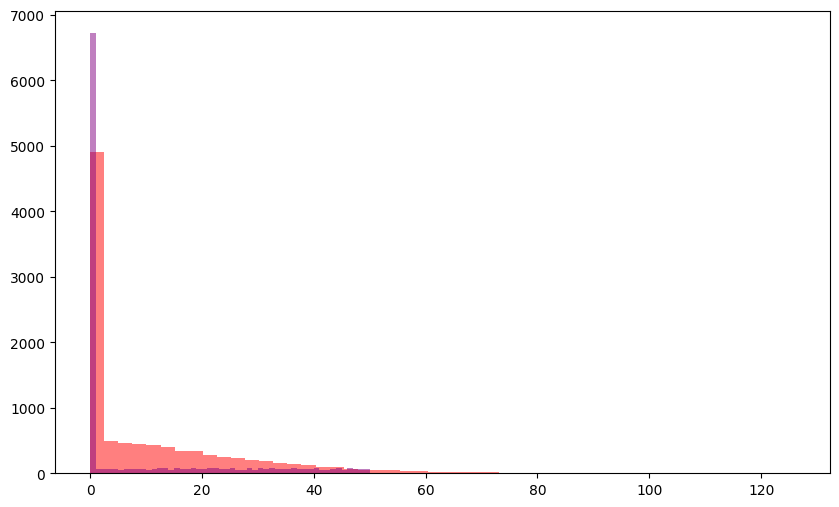

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(
    simul_call,
    bins=50,
    alpha=0.5,
    color="red"
    );

plt.hist(
    simul_put,
    bins=50,
    alpha=0.5,
    color="purple"
    );

## Ganancia promedio simulada

El promedio de los payoffs simulados es la estimación Monte Carlo de la ganancia esperada al vencimiento, bajo la medida neutral al riesgo. Para llegar al precio justo de la opción hoy, ese valor esperado se tendría que descontar a valor presente multiplicando por $e^{-rT}$; aquí solo se calcula la ganancia esperada, sin ese último paso de descuento.

In [7]:
simul_call.mean()

np.float64(10.985961590306978)

In [8]:
simul_put.mean()

np.float64(8.370473163435143)

## Punto de partida para el análisis de sensibilidad

Las siguientes celdas repiten la configuración de la simulación GBM —mismos parámetros y misma semilla— para dejar un punto de arranque limpio antes de mover un parámetro a la vez: volatilidad, tasa y plazo, y observar su efecto sobre la ganancia esperada de call y put.

In [9]:
np.random.seed(42)
S = 100
k = 100
r = 0.05
sigma = 0.2
T = 1 
M = 10000

Z = np.random.normal(0, 1, M)

ST = S*np.exp((r - (0.5 * sigma ** 2)) * T + sigma * np.sqrt(T) * Z)
ST



array([113.8080226 , 100.23498965, 117.29684912, ...,  89.4882061 ,
       113.78643345, 117.21945676], shape=(10000,))

In [10]:
simul_call = np.maximum(ST - k,0)
simul_put = np.maximum(k - st, 0)

## Sensibilidad a la volatilidad

Aquí se repite la simulación de $S_T$ para distintos valores de $\sigma$ (10%, 20%, 40%, 60%), manteniendo fijos $r$, $K$ y $T$, y se calcula la ganancia promedio de call y put en cada caso.

Entre más alta la volatilidad, más ancha es la distribución de $S_T$: hay más probabilidad de que el precio termine lejos del strike, en cualquier dirección. Eso favorece tanto al call como al put, porque ambos tienen la pérdida máxima limitada a cero —a mayor incertidumbre, mayor ganancia esperada para las dos opciones.

In [14]:
volatilidades = [0.10, 0.20, 0.30, 0.40, 0.50]
resultados_volatilidad = []

np.random.seed(42)
Z = np.random.normal(0, 1, M)

for volatilidad in volatilidades:
    ST = S * np.exp(
        (r - 0.5 * volatilidad**2) * T
        + volatilidad * np.sqrt(T) * Z
    )
    resultados_volatilidad.append({
        "Volatilidad": f"{volatilidad:.0%}",
        "Ganancia promedio Call": np.maximum(ST - k, 0).mean(),
        "Ganancia promedio Put": np.maximum(k - ST, 0).mean()
    })

pd.DataFrame(resultados_volatilidad).round(2)

,Volatilidad,Ganancia promedio Call,Ganancia promedio Put
0,10%,7.15,2.04
1,20%,10.99,5.89
2,30%,14.97,9.87
3,40%,18.97,13.87
4,50%,22.96,17.84


## Sensibilidad a la tasa libre de riesgo

Ahora se varía $r$ (5%, 10%, 20%), dejando $\sigma$ y $T$ fijos. La tasa entra en la deriva de GBM: una $r$ más alta empuja la distribución de $S_T$ hacia arriba, lo que favorece al call (su ganancia promedio sube) y perjudica al put (su ganancia promedio baja), porque el precio esperado se aleja hacia arriba del strike.

In [16]:
tasas = [0.05, 0.10, 0.15, 0.20]
resultados_tasa = []

np.random.seed(42)
Z = np.random.normal(0, 1, M)

for tasa in tasas:
    ST = S * np.exp(
        (tasa - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )
    resultados_tasa.append({
        "Tasa r": f"{tasa:.0%}",
        "Ganancia promedio Call": np.maximum(ST - k, 0).mean(),
        "Ganancia promedio Put": np.maximum(k - ST, 0).mean()
    })

pd.DataFrame(resultados_tasa).round(2)

,Tasa r,Ganancia promedio Call,Ganancia promedio Put
0,5%,10.99,5.89
1,10%,14.66,4.17
2,15%,18.99,2.84
3,20%,23.96,1.85


## Sensibilidad al plazo

Por último se varía el tiempo a vencimiento $T$ (0.25, 0.5, 1 y 2 años), con $r$ y $\sigma$ fijos en sus valores base. En GBM tanto la deriva como el componente aleatorio dependen de $T$ —el aleatorio escala con $\sqrt{T}$—, así que a mayor plazo, mayor dispersión de $S_T$. Igual que con la volatilidad, más tiempo significa más incertidumbre acumulada, lo que en general incrementa la ganancia promedio esperada de ambas opciones.

In [15]:
tiempos = [0.25, 0.5, 1, 1.5, 2]
tasa_base = 0.05
volatilidad_base = 0.20
resultados_tiempo = []

np.random.seed(42)
Z = np.random.normal(0, 1, M)

for plazo in tiempos:
    ST = S * np.exp(
        (tasa_base - 0.5 * volatilidad_base**2) * plazo
        + volatilidad_base * np.sqrt(plazo) * Z
    )
    resultados_tiempo.append({
        "Tiempo": plazo,
        "Ganancia promedio Call": np.maximum(ST - k, 0).mean(),
        "Ganancia promedio Put": np.maximum(k - ST, 0).mean()
    })

pd.DataFrame(resultados_tiempo).round(2)

,Tiempo,Ganancia promedio Call,Ganancia promedio Put
0,0.25,4.67,3.43
1,0.50,7.06,4.55
2,1.00,10.99,5.89
3,1.50,14.49,6.73
4,2.00,17.82,7.34


## Parte 3. Visualización

Hasta aquí, el precio de la opción se estimaba simulando miles de trayectorias con Monte Carlo. Black y Scholes resolvieron la misma pregunta de forma cerrada en 1973 (con el ajuste de Merton poco después): en vez de simular, despejaron una fórmula exacta a partir de la misma ecuación diferencial que describe el movimiento del precio.

La fórmula depende de dos términos intermedios, $d_1$ y $d_2$, que miden qué tan lejos está $S$ del strike $K$, ajustado por el tiempo y la volatilidad:

$$d_1 = \frac{\ln(S/K) + \left(r + \tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}} \qquad\qquad d_2 = d_1 - \sigma\sqrt{T}$$

$N(\cdot)$ es la función de distribución acumulada normal estándar: $N(d)$ es la probabilidad de que una variable $N(0,1)$ caiga por debajo de $d$. Con eso:

$$C = S \cdot N(d_1) - K e^{-rT} \cdot N(d_2)$$
$$P = K e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)$$

El call y el put comparten $d_1$ y $d_2$, pero el put usa $N(-d_1)$ y $N(-d_2)$ en vez de $N(d_1)$ y $N(d_2)$ — de ahí que valgan distinto aunque partan de los mismos parámetros.

Con esa fórmula ya se puede mover un parámetro a la vez y graficar cómo cambia el precio de la opción, sin necesidad de volver a simular nada: precio del activo, strike, volatilidad, tiempo y tasa libre de riesgo, cada uno con su propia gráfica de call contra put.

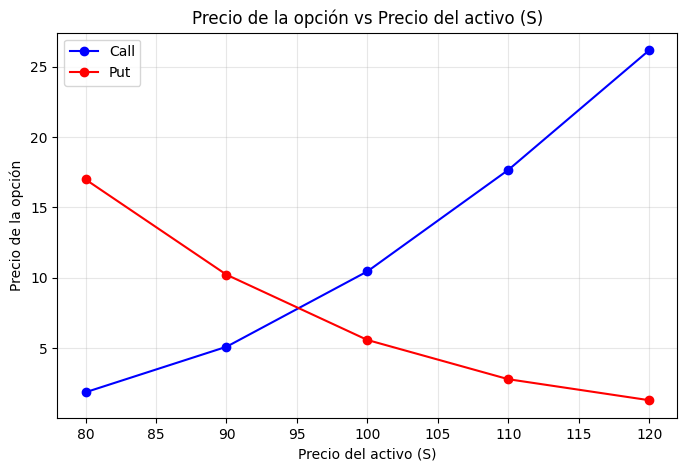

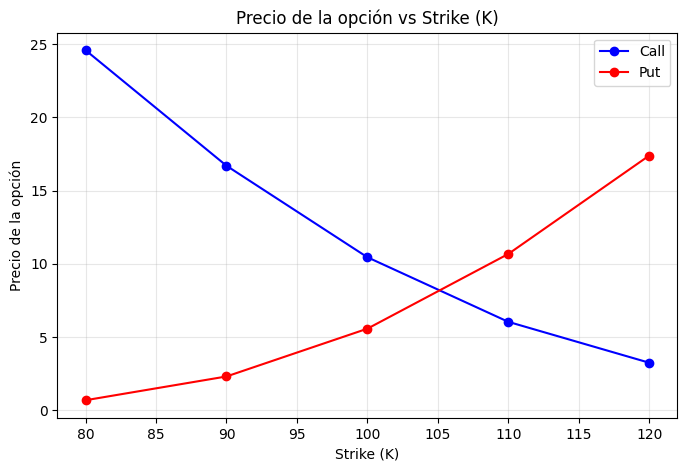

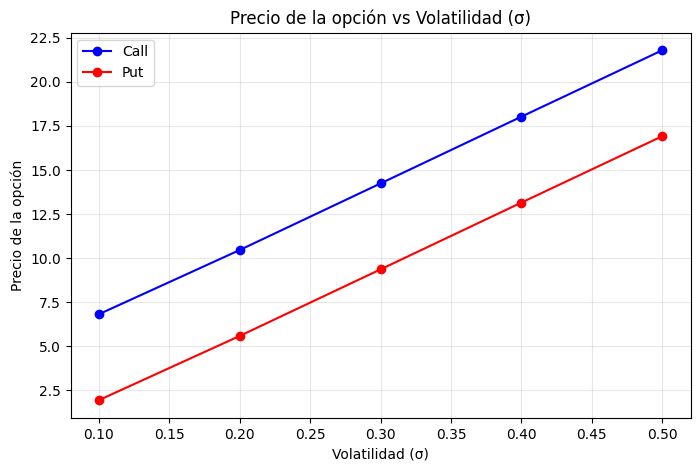

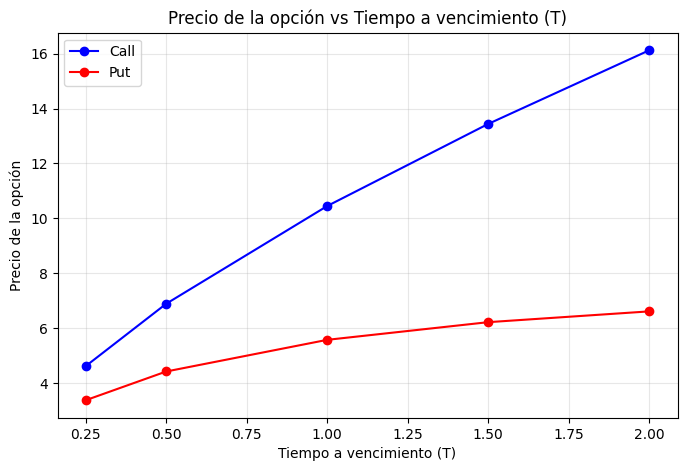

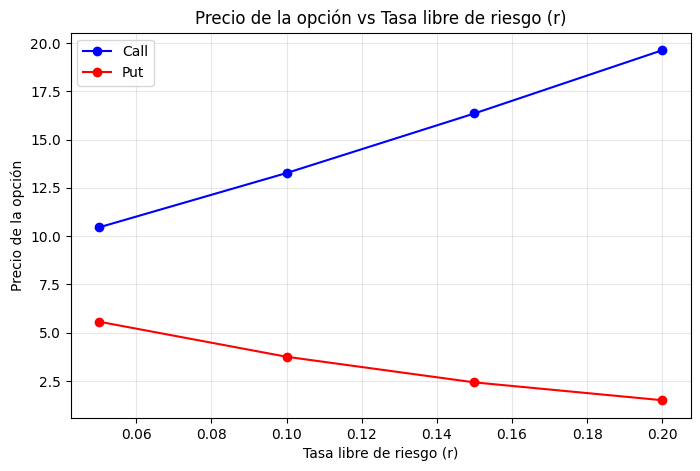

In [17]:
from scipy.stats import norm

# Fórmula cerrada de Black-Scholes
def bs_call(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put(S, K, r, sigma, T):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Parámetros base
S0, K0, r0, sigma0, T0 = 100, 100, 0.05, 0.20, 1

def graficar_sensibilidad(x, call_vals, put_vals, xlabel):
    plt.figure(figsize=(8, 5))
    plt.plot(x, call_vals, marker="o", label="Call", color="blue")
    plt.plot(x, put_vals, marker="o", label="Put", color="red")
    plt.xlabel(xlabel)
    plt.ylabel("Precio de la opción")
    plt.title(f"Precio de la opción vs {xlabel}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 1. Precio del activo
precios_S = [80, 90, 100, 110, 120]
call_S = [bs_call(S, K0, r0, sigma0, T0) for S in precios_S]
put_S  = [bs_put(S, K0, r0, sigma0, T0) for S in precios_S]
graficar_sensibilidad(precios_S, call_S, put_S, "Precio del activo (S)")

# 2. Strike
strikes = [80, 90, 100, 110, 120]
call_K = [bs_call(S0, K, r0, sigma0, T0) for K in strikes]
put_K  = [bs_put(S0, K, r0, sigma0, T0) for K in strikes]
graficar_sensibilidad(strikes, call_K, put_K, "Strike (K)")

# 3. Volatilidad
volatilidades = [0.10, 0.20, 0.30, 0.40, 0.50]
call_sigma = [bs_call(S0, K0, r0, sigma, T0) for sigma in volatilidades]
put_sigma  = [bs_put(S0, K0, r0, sigma, T0) for sigma in volatilidades]
graficar_sensibilidad(volatilidades, call_sigma, put_sigma, "Volatilidad (σ)")

# 4. Tiempo
tiempos = [0.25, 0.5, 1, 1.5, 2]
call_T = [bs_call(S0, K0, r0, sigma0, T) for T in tiempos]
put_T  = [bs_put(S0, K0, r0, sigma0, T) for T in tiempos]
graficar_sensibilidad(tiempos, call_T, put_T, "Tiempo a vencimiento (T)")

# 5. Rendimiento (tasa libre de riesgo, r)
tasas = [0.05, 0.10, 0.15, 0.20]
call_r = [bs_call(S0, K0, r, sigma0, T0) for r in tasas]
put_r  = [bs_put(S0, K0, r, sigma0, T0) for r in tasas]
graficar_sensibilidad(tasas, call_r, put_r, "Tasa libre de riesgo (r)")

## Parte 4. Interpretación

### Precio del activo

Una call da derecho a comprar a un precio fijo $K$. Si $S$ sube, la diferencia $S - K$ crece, y como el call se queda con esa diferencia cuando es positiva, su valor sube junto con $S$.

Una put es lo contrario: da derecho a vender a $K$. Si $S$ sube, vender a $K$ vale cada vez menos frente al mercado, así que el valor de la put baja. Por eso las dos líneas se mueven en direcciones opuestas conforme $S$ se aleja del strike.

### Volatilidad

Una mayor volatilidad siempre aumenta el valor de la opción, nunca lo disminuye. La razón es la asimetría del payoff: la pérdida máxima está topada en la prima, pero la ganancia no (call) o está acotada por $K$ pero puede ser grande (put). Más incertidumbre en $S_T$ ensancha la distribución de precios posibles, y como el lado malo ya está limitado, ese ensanchamiento solo suma valor esperado.

### Tiempo

Más tiempo casi siempre aumenta el valor de la opción, por la misma lógica que la volatilidad: más tiempo acumula más incertidumbre. Pero no es deseable para todos por igual:

- Para quien compra la opción (long call o long put), más tiempo es bueno: paga más prima, pero tiene más margen para que el mercado se mueva a su favor.
- Para quien la vende (short call o short put), más tiempo es una carga: cobra más prima, pero asume el riesgo por más tiempo.

### Strike

El strike define qué tan fácil es terminar in-the-money. Un call con strike bajo ya está cerca de in-the-money y solo necesita que el precio no caiga demasiado; con strike alto necesita que el precio suba mucho. Con el put es al revés: strike alto favorece terminar in-the-money, strike bajo lo dificulta.

**In-the-money (ITM):** una opción está in-the-money cuando ejercerla hoy generaría una ganancia, es decir, cuando su valor intrínseco es positivo. Para un call, eso pasa cuando $S > K$; para un put, cuando $S < K$. Cuando $S = K$ está at-the-money, y cuando ejercerla daría pérdida, está out-of-the-money.